# Logistic regression and softmax regression

Two course colabs merged ("MNIST digits classification" and "softmax regression with MNIST"). Same 0-detector
as the perceptron notebook, then all ten digits:

1. logistic regression trained with SGD (`SGDClassifier`), with and without regularisation
2. tuning with `RandomizedSearchCV`, learning curves, PR and ROC curves
3. `LogisticRegression` with proper solvers, `GridSearchCV` vs `LogisticRegressionCV`
4. `RidgeClassifier` (least squares classification)
5. multiclass: one-vs-rest and softmax (multinomial)

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import loguniform

from sklearn.datasets import fetch_openml
from sklearn.dummy import DummyClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import SGDClassifier, LogisticRegression, LogisticRegressionCV, RidgeClassifier
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report, precision_score, recall_score,
                             f1_score, log_loss, precision_recall_curve, average_precision_score,
                             roc_curve, roc_auc_score)
from sklearn.model_selection import cross_validate, GridSearchCV, RandomizedSearchCV, learning_curve, ShuffleSplit
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

np.random.seed(42)
warnings.simplefilter("ignore", ConvergenceWarning)

In [2]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X, y = X.to_numpy(), y.to_numpy()
x_train, x_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# 0-detector, labels 1 / 0 this time
y_train_0 = (y_train == '0').astype(int)
y_test_0 = (y_test == '0').astype(int)

For logistic regression the labels are 0/1 (the perceptron used -1/+1).

Scaling the pixels to [0, 1] matters more here than for the perceptron: the sigmoid saturates for large
inputs, and with raw 0-255 values the weighted sums are huge, the gradients vanish and training crawls.
Mean-centring (`StandardScaler`) isn't a great fit for images either: it turns all the background zeros
into non-zero values and blows up the rare pixels near the border.

In [3]:
base = DummyClassifier(strategy='most_frequent').fit(x_train, y_train_0)
print(f"baseline accuracy: {base.score(x_train, y_train_0):.4f}")

baseline accuracy: 0.9013


## Logistic regression with SGD

Model: $z = \mathbf{w}^T\mathbf{x} + b$, probability $\sigma(z) = 1 / (1 + e^{-z})$.

Loss (binary cross entropy):

$$J(\mathbf{w}) = -\frac{1}{n}\sum_i \left[ y_i \log \sigma(z_i) + (1 - y_i) \log(1 - \sigma(z_i)) \right]$$

`SGDClassifier(loss='log_loss')` minimises this with SGD. (It was `loss='log'` in the course; that name was
removed in sklearn 1.3.)

### No regularisation

`alpha=0` turns off the penalty. Constant learning rate 0.01. One `partial_fit` call per epoch so the
loss can be tracked.

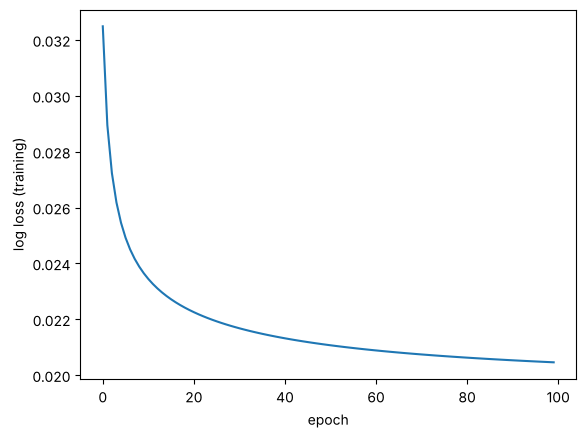

In [4]:
scaler = MinMaxScaler().fit(x_train)
xs_train, xs_test = scaler.transform(x_train), scaler.transform(x_test)

def train_sgd(alpha, epochs=100):
    clf = SGDClassifier(loss='log_loss', penalty='l2', alpha=alpha, eta0=0.01,
                        learning_rate='constant', random_state=1729)
    losses = []
    for _ in range(epochs):
        clf.partial_fit(xs_train, y_train_0, classes=[0, 1])
        losses.append(log_loss(y_train_0, clf.predict_proba(xs_train)))
    return clf, losses

sgd, loss_sgd = train_sgd(alpha=0)
plt.plot(loss_sgd)
plt.xlabel('epoch'); plt.ylabel('log loss (training)')
plt.show()

The loss goes down steadily: it's training as expected. (The course used `warm_start=True` with
`max_iter=1` in a loop; `partial_fit` does the same thing directly.)

In [5]:
def report(name, model, X_tr, X_te):
    print(f"{name}: train acc {model.score(X_tr, y_train_0):.4f}   test acc {model.score(X_te, y_test_0):.4f}")
    print(classification_report(y_test_0, model.predict(X_te), digits=3))

report("SGD logistic, no penalty", sgd, xs_train, xs_test)

SGD logistic, no penalty: train acc 0.9940   test acc 0.9919
              precision    recall  f1-score   support

           0      0.996     0.995     0.996      9020
           1      0.956     0.961     0.959       980

    accuracy                          0.992     10000
   macro avg      0.976     0.978     0.977     10000
weighted avg      0.992     0.992     0.992     10000



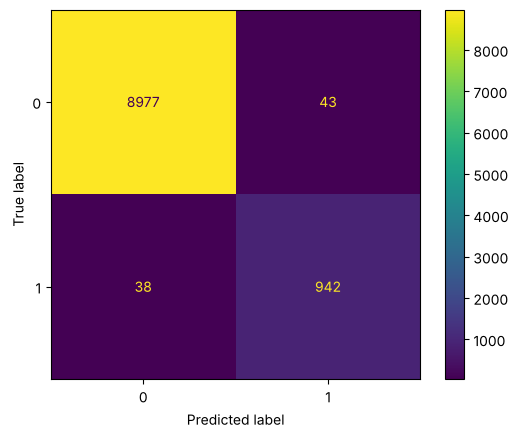

In [6]:
ConfusionMatrixDisplay.from_predictions(y_test_0, sgd.predict(xs_test), values_format='d')
plt.show()

### Cross validation

In [7]:
pipe_sgd_cv = make_pipeline(MinMaxScaler(),
                            SGDClassifier(loss='log_loss', alpha=0, eta0=0.01, learning_rate='constant',
                                          max_iter=100, random_state=1729))
cv_res = cross_validate(pipe_sgd_cv, x_train, y_train_0, cv=5, scoring=['precision', 'recall', 'f1'],
                        return_train_score=True)
pd.DataFrame({m: [cv_res[f'train_{m}'].mean(), cv_res[f'test_{m}'].mean(), cv_res[f'test_{m}'].std()]
              for m in ['precision', 'recall', 'f1']}, index=['train', 'valid', 'valid std']).round(3)

,precision,recall,f1
train,0.971,0.958,0.964
valid,0.964,0.953,0.958
valid std,0.006,0.006,0.002


### Looking at the weights

bias: [-4.89339106]  weights exactly zero: 67


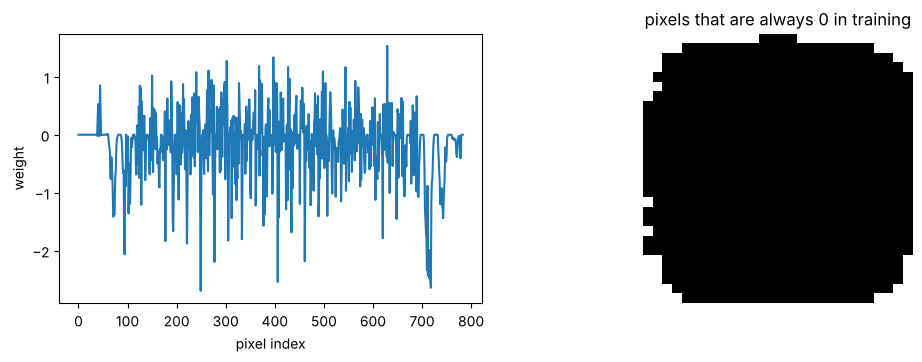

In [8]:
w = sgd.coef_.ravel()
print("bias:", sgd.intercept_, " weights exactly zero:", (w == 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(w); axes[0].set_xlabel('pixel index'); axes[0].set_ylabel('weight')
axes[1].imshow((x_train.max(axis=0) == 0).reshape(28, 28), cmap='gray')
axes[1].set_title('pixels that are always 0 in training'); axes[1].axis('off')
plt.show()

67 weights are exactly zero. That's not the model deciding those features are useless: those pixels are
**always** 0 in every training image (the border), so their gradient is always 0 and the weight never moves
from its starting value. Training and test performance are close, so there's no sign that regularisation
is needed.

### With L2 regularisation

Out of curiosity, a small penalty `alpha=0.001`:

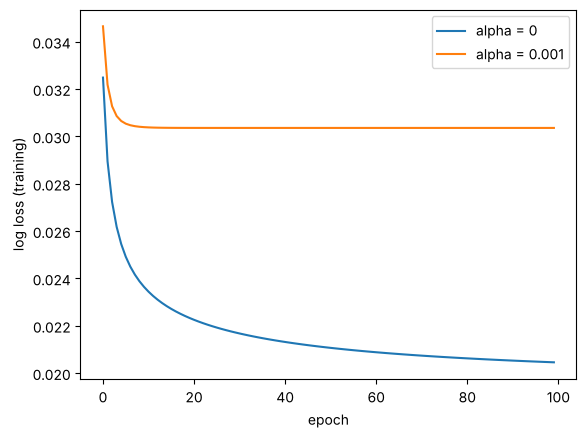

SGD logistic, L2 alpha=0.001: train acc 0.9907   test acc 0.9905
              precision    recall  f1-score   support

           0      0.993     0.996     0.995      9020
           1      0.964     0.938     0.951       980

    accuracy                          0.991     10000
   macro avg      0.979     0.967     0.973     10000
weighted avg      0.990     0.991     0.990     10000



In [9]:
sgd_l2, loss_l2 = train_sgd(alpha=0.001)

plt.plot(loss_sgd, label='alpha = 0')
plt.plot(loss_l2, label='alpha = 0.001')
plt.xlabel('epoch'); plt.ylabel('log loss (training)'); plt.legend()
plt.show()

report("SGD logistic, L2 alpha=0.001", sgd_l2, xs_train, xs_test)

The training loss ends a bit higher (the penalty stops the weights from fitting as closely), and the
test metrics drop slightly. Same 67 zero weights, since L2 shrinks weights but doesn't set them to zero.

### Some predictions

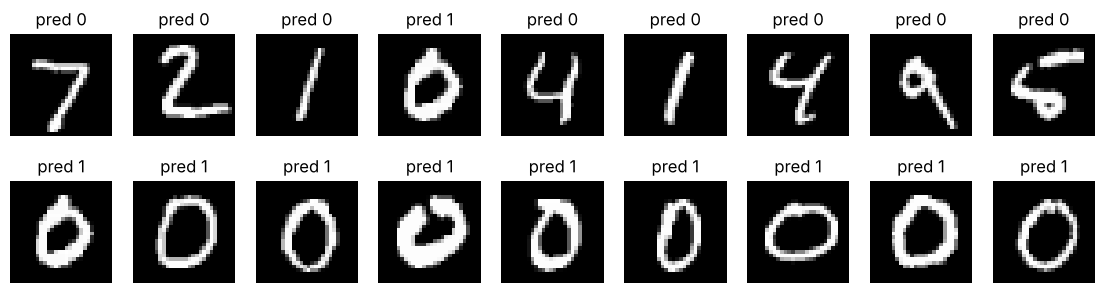

In [10]:
y_hat_test = sgd.predict(xs_test)
zeros = np.where(y_test_0 == 1)[0]

fig, axes = plt.subplots(2, 9, figsize=(14, 3.5))
for ax, i in zip(axes[0], range(9)):
    ax.imshow(x_test[i].reshape(28, 28), cmap='gray'); ax.set_title(f"pred {y_hat_test[i]}"); ax.axis('off')
for ax, i in zip(axes[1], zeros[:9]):
    ax.imshow(x_test[i].reshape(28, 28), cmap='gray'); ax.set_title(f"pred {y_hat_test[i]}"); ax.axis('off')
axes[0, 0].set_ylabel('first 9'); axes[1, 0].set_ylabel('actual 0s')
plt.show()

### Hyperparameter search

Learning rate and regularisation strength, sampled from log-uniform distributions. The course used 5-fold
CV here and noted it "takes quite a long time", so this uses 3 folds and 10 samples.

In [11]:
pipe = make_pipeline(MinMaxScaler(),
                     SGDClassifier(loss='log_loss', learning_rate='constant', max_iter=100, random_state=1729))
search = RandomizedSearchCV(pipe, param_distributions={
                                'sgdclassifier__eta0': loguniform(1e-3, 1e-1),
                                'sgdclassifier__alpha': loguniform(1e-7, 1e-1)},
                            cv=3, scoring='precision', n_iter=10, random_state=1729, n_jobs=-1)
search.fit(x_train, y_train_0)

res = pd.DataFrame(search.cv_results_)[['param_sgdclassifier__alpha', 'param_sgdclassifier__eta0', 'mean_test_score']]
res.columns = ['alpha', 'eta0', 'CV precision']
res.sort_values('CV precision', ascending=False).round(5)

,alpha,eta0,CV precision
4,0.05829,0.01350,0.98938
8,0.05812,0.01691,0.98804
2,0.00142,0.02860,0.97300
7,0.00001,0.01057,0.95686
0,0.00000,0.00330,0.95624
3,0.00001,0.00322,0.95623
6,0.00011,0.00285,0.95222
5,0.00000,0.02929,0.93484
1,0.00003,0.02750,0.92080
9,0.00327,0.06321,0.88426


In [12]:
best_sgd = search.best_estimator_
y_hat = best_sgd.predict(x_test)
print(f"best: alpha {search.best_params_['sgdclassifier__alpha']:.2e}, eta0 {search.best_params_['sgdclassifier__eta0']:.4f}")
print(f"test precision {precision_score(y_test_0, y_hat):.3f}   recall {recall_score(y_test_0, y_hat):.3f}")

best: alpha 5.83e-02, eta0 0.0135
test precision 0.974   recall 0.789


The course asked why the tuned model came out *worse* than the hand-set one. The answer is the scoring:
the search maximised **precision only**, and a heavily regularised model can get very high precision by
predicting "0" only when it's really sure, at the cost of missing a lot of real zeros. Optimising one
metric in isolation gets you exactly that metric. `scoring='f1'` (or `average_precision`) would balance both.

### Learning curve

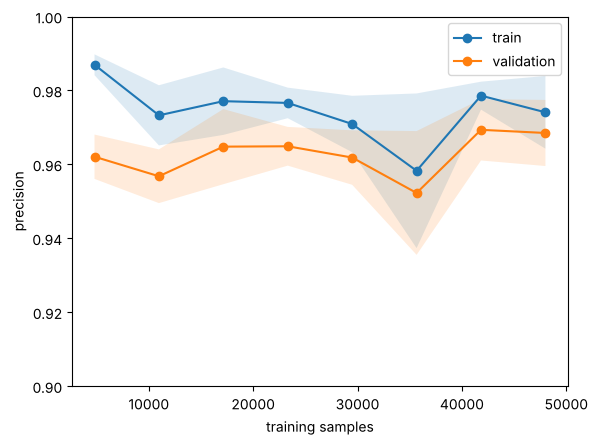

In [13]:
train_sizes, train_scores, test_scores = learning_curve(
    pipe_sgd_cv, x_train, y_train_0, cv=ShuffleSplit(n_splits=5, test_size=0.2, random_state=0),
    scoring='precision', train_sizes=np.linspace(0.1, 1, 8), n_jobs=-1)

for scores, label in [(train_scores, 'train'), (test_scores, 'validation')]:
    m, s = scores.mean(axis=1), scores.std(axis=1)
    plt.plot(train_sizes, m, 'o-', label=label)
    plt.fill_between(train_sizes, m - s, m + s, alpha=0.15)
plt.xlabel('training samples'); plt.ylabel('precision'); plt.legend(); plt.ylim(0.9, 1)
plt.show()

The two curves meet as the data grows, and the validation curve flattens: more data won't help much.

### PR and ROC curves

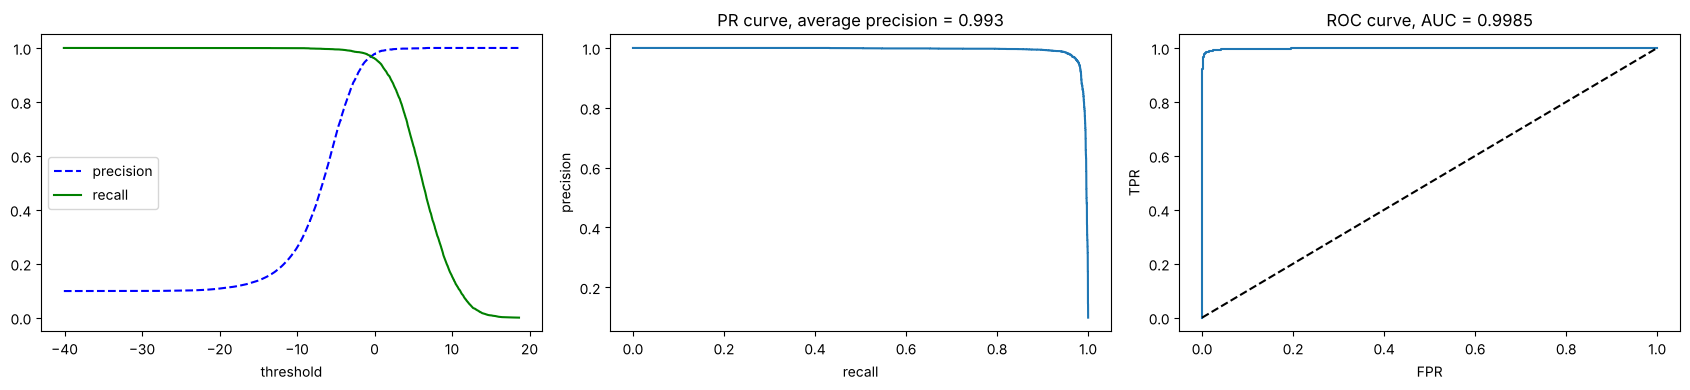

In [14]:
y_scores = sgd.decision_function(xs_train)
precisions, recalls, thresholds = precision_recall_curve(y_train_0, y_scores)
fpr, tpr, _ = roc_curve(y_train_0, y_scores)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].plot(thresholds, precisions[:-1], 'b--', label='precision')
axes[0].plot(thresholds, recalls[:-1], 'g-', label='recall')
axes[0].set_xlabel('threshold'); axes[0].legend()
axes[1].plot(recalls, precisions); axes[1].set_xlabel('recall'); axes[1].set_ylabel('precision')
axes[1].set_title(f"PR curve, average precision = {average_precision_score(y_train_0, y_scores):.3f}")
axes[2].plot(fpr, tpr); axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_title(f"ROC curve, AUC = {roc_auc_score(y_train_0, y_scores):.4f}")
plt.tight_layout()
plt.show()

`average_precision_score` is the usual way to summarise a PR curve. The course used `auc(recall, precision)`
(trapezoid rule), which can be a bit optimistic because it interpolates linearly between points.

---

## LogisticRegression

Same model, but fitted with a proper optimiser (`lbfgs` by default, also `liblinear`, `newton-cg`, `sag`,
`saga`) instead of SGD. Regularisation is on by default and controlled by `C`, the **inverse** of the
strength: small `C` = strong regularisation.

### Without regularisation

In [15]:
pipe_logit = make_pipeline(MinMaxScaler(), LogisticRegression(penalty=None, max_iter=1000, random_state=1729))
pipe_logit.fit(x_train, y_train_0)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('minmaxscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,784
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value


`penalty=None` replaces the `C=np.infty` from the course (`np.infty` no longer exists in NumPy 2).

### GridSearchCV over C

In [16]:
grid_Cs = [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0]
pipe_logit_gs = GridSearchCV(Pipeline([("scaler", MinMaxScaler()),
                                       ("logistic", LogisticRegression(max_iter=1000, random_state=1729))]),
                             param_grid={"logistic__C": grid_Cs}, scoring='f1', n_jobs=-1)
pipe_logit_gs.fit(x_train, y_train_0)
print("best:", pipe_logit_gs.best_params_, f" CV F1 {pipe_logit_gs.best_score_:.4f}")

best: {'logistic__C': 0.1}  CV F1 0.9583


The course grid started with `C=0`, which isn't valid (it would mean infinite regularisation) and is
rejected by current sklearn.

### LogisticRegressionCV

Does the same search internally, and can be faster because it reuses the solution for one `C` as the
starting point for the next.

In [17]:
logit_cv = make_pipeline(MinMaxScaler(), LogisticRegressionCV(Cs=grid_Cs, cv=5, scoring='f1', max_iter=1000,
                                                              random_state=1729, n_jobs=-1))
logit_cv.fit(x_train, y_train_0)
print("best C:", logit_cv[-1].C_)

best C: [1.]


In [18]:
rows = []
for name, model in [("no regularisation", pipe_logit), ("GridSearchCV", pipe_logit_gs),
                    ("LogisticRegressionCV", logit_cv)]:
    y_hat = model.predict(x_test)
    scores = model.decision_function(x_test)
    rows.append({"model": name, "precision": precision_score(y_test_0, y_hat),
                 "recall": recall_score(y_test_0, y_hat), "F1": f1_score(y_test_0, y_hat),
                 "average precision": average_precision_score(y_test_0, scores)})
pd.DataFrame(rows).set_index("model").round(4)

,precision,recall,F1,average precision
model,,,,
no regularisation,0.9545,0.9633,0.9589,0.9883
GridSearchCV,0.9556,0.9653,0.9604,0.9895
LogisticRegressionCV,0.9545,0.9633,0.9589,0.9890


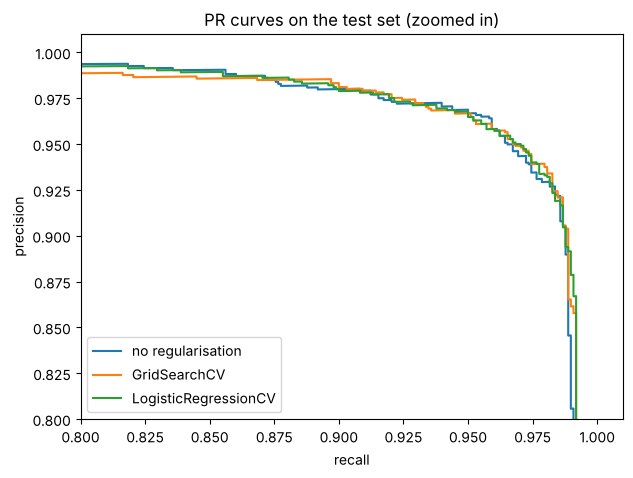

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, model in [("no regularisation", pipe_logit), ("GridSearchCV", pipe_logit_gs),
                    ("LogisticRegressionCV", logit_cv)]:
    p, r, _ = precision_recall_curve(y_test_0, model.decision_function(x_test))
    ax.plot(r, p, label=name)
ax.set_xlabel('recall'); ax.set_ylabel('precision'); ax.set_xlim(0.8, 1.01); ax.set_ylim(0.8, 1.01)
ax.legend(); ax.set_title('PR curves on the test set (zoomed in)')
plt.show()

All three are very close. A bit of regularisation helps slightly, but there isn't much overfitting to fix
on this problem.

## RidgeClassifier

Treats classification as regression: fit a ridge regression to targets of -1/+1 and predict the sign.
It has a closed-form solution, so it's fast, but squared error isn't a natural loss for classification:
points that are "too correct" (far on the right side) still get penalised.

In [20]:
pipe_ridge = make_pipeline(MinMaxScaler(), RidgeClassifier(alpha=0))
pipe_ridge.fit(x_train, y_train_0)
print(classification_report(y_test_0, pipe_ridge.predict(x_test), digits=3))

              precision    recall  f1-score   support

           0      0.987     0.996     0.991      9020
           1      0.956     0.882     0.917       980

    accuracy                          0.984     10000
   macro avg      0.971     0.939     0.954     10000
weighted avg      0.984     0.984     0.984     10000



Noticeably lower recall than logistic regression. (`normalize=False` from the course was removed in
sklearn 1.2, and `RidgeClassifier` handles 0/1 labels itself, there's no need to convert to -1/+1 first.)

The course then picked the CV fold with the highest *training* F1 as the "best" model. That's choosing on
noise: all folds are the same model on slightly different data. Refitting on all the training data is the
normal approach.

### What each model learned

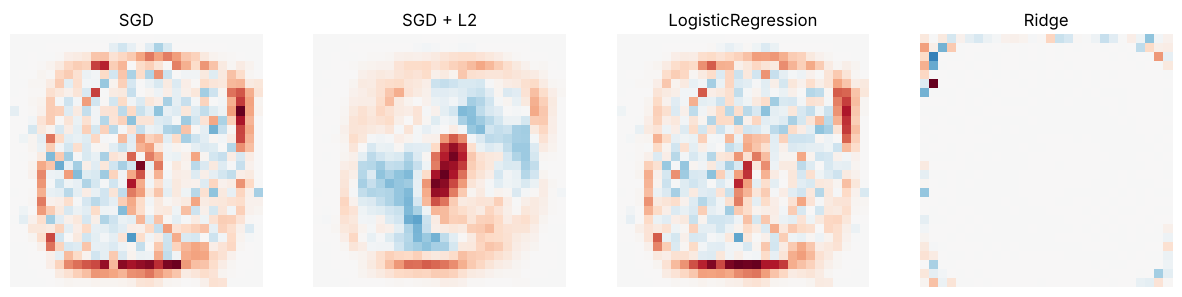

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, (title, coef) in zip(axes, [("SGD", sgd.coef_), ("SGD + L2", sgd_l2.coef_),
                                    ("LogisticRegression", pipe_logit[-1].coef_), ("Ridge", pipe_ridge[-1].coef_)]):
    lim = np.abs(coef).max()
    ax.imshow(coef.reshape(28, 28), cmap='RdBu', vmin=-lim, vmax=lim)
    ax.set_title(title); ax.axis('off')
plt.show()

Blue = positive weight (evidence for "0"), red = negative.

The L2-regularised SGD model gives the clearest picture: a blue ring where zeros have ink, and a red stroke
through the middle, where 1s and 7s have ink but a 0 is empty.

Without a penalty (plain SGD and `LogisticRegression(penalty=None)`) the picture is mostly speckle, and the
largest weights sit on pixels near the edge of the image. Those pixels are blank in almost every training
image, `MinMaxScaler` stretches their few non-zero values to the full [0, 1] range, and with no penalty the
model is free to give them big weights to fit a handful of images. Ridge with `alpha=0` is the extreme case:
a few corner pixels get such huge weights that everything else is washed out on the shared colour scale.

That's an argument for regularisation even when it barely changes the accuracy: the model it produces is
much more sensible.

---

## Multiclass

### One-vs-rest with SGD

Passing all ten labels to `SGDClassifier` trains ten binary classifiers. The course trained 100 epochs
with a warm-start loop and noted it took about 5 minutes. 20 epochs is enough to show the idea.

In [22]:
sgd_ovr = make_pipeline(MinMaxScaler(), SGDClassifier(loss='log_loss', alpha=0, eta0=0.01,
                                                      learning_rate='constant', max_iter=20, random_state=1729))
sgd_ovr.fit(x_train, y_train)
print("coef shape:", sgd_ovr[-1].coef_.shape)
print(classification_report(y_test, sgd_ovr.predict(x_test)))

coef shape: (10, 784)
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       980
           1       0.96      0.97      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.93      0.89      0.91      1010
           4       0.90      0.94      0.92       982
           5       0.87      0.88      0.88       892
           6       0.92      0.95      0.94       958
           7       0.93      0.92      0.92      1028
           8       0.87      0.86      0.87       974
           9       0.93      0.86      0.89      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



### Softmax regression (multinomial logistic regression)

Instead of ten separate yes/no models, one model with a weight vector per class and a softmax over
the ten scores:

$$P(y = k \mid \mathbf{x}) = \frac{e^{\mathbf{w}_k^T\mathbf{x}}}{\sum_j e^{\mathbf{w}_j^T\mathbf{x}}}$$

trained with the multiclass cross entropy loss. The probabilities add up to 1 across classes, and all
classes are trained together. `LogisticRegression` uses this by default for multiclass problems with the
`lbfgs` solver (the course set `multi_class='multinomial'`, a parameter deprecated in sklearn 1.5 since
it's now the default).

The softmax colab used `StandardScaler` and the `sag` solver:

In [23]:
softmax = Pipeline([('scaler', StandardScaler()),
                    ('logreg', LogisticRegression(solver='sag', max_iter=100, random_state=1729))])
softmax.fit(x_train, y_train)
print("coef:", softmax[-1].coef_.shape, " intercept:", softmax[-1].intercept_.shape)
print("classes:", softmax[-1].classes_)

coef: (10, 784)  intercept: (10,)
classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


In [24]:
y_hat = softmax.predict(x_test)
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.96      0.98      0.97      1135
           2       0.94      0.90      0.92      1032
           3       0.91      0.91      0.91      1010
           4       0.92      0.94      0.93       982
           5       0.91      0.87      0.89       892
           6       0.93      0.95      0.94       958
           7       0.92      0.93      0.92      1028
           8       0.88      0.88      0.88       974
           9       0.91      0.91      0.91      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



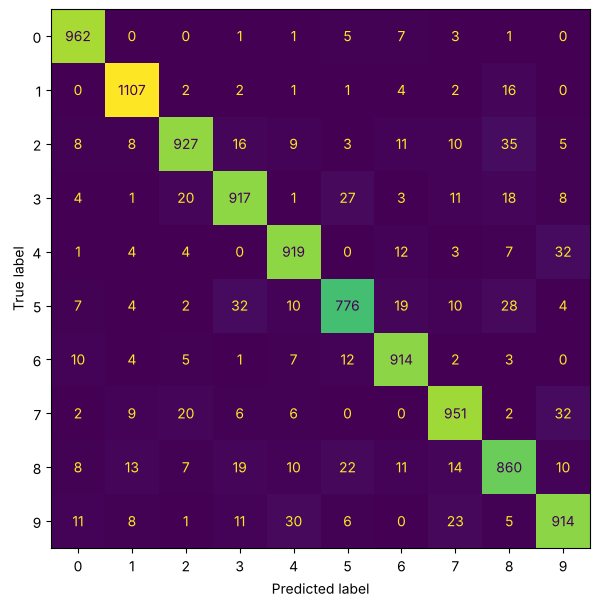

In [25]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(y_test, y_hat, values_format='d', ax=ax, colorbar=False)
plt.show()

About 92% accuracy. `sag` didn't fully converge in 100 iterations (that's what the course's convergence
warnings were about), but more iterations barely change the result.

The probabilities for a few test images:

In [26]:
pd.DataFrame(softmax.predict_proba(x_test[:5]), columns=softmax[-1].classes_).round(3).assign(actual=y_test[:5])

,0,1,2,3,4,5,6,7,8,9,actual
0,0.000,0.000,0.000,0.002,0.000,0.000,0.000,0.997,0.000,0.00,7
1,0.001,0.000,0.995,0.000,0.000,0.000,0.003,0.000,0.000,0.00,2
2,0.000,0.966,0.015,0.003,0.001,0.001,0.003,0.009,0.002,0.00,1
3,0.999,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0
4,0.001,0.000,0.001,0.000,0.968,0.000,0.003,0.006,0.001,0.02,4


### Weights per class

Each row of `coef_` is a 28x28 template for one digit:

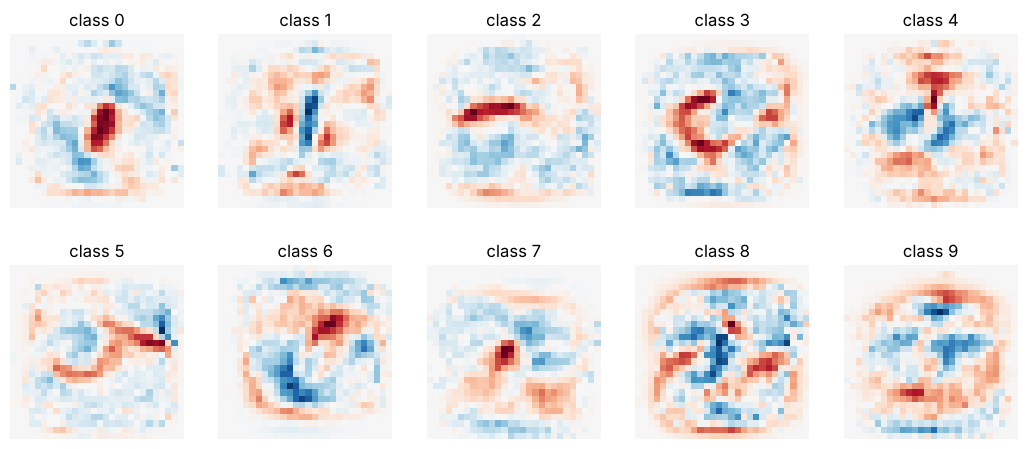

In [27]:
W = softmax[-1].coef_
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
for k, ax in enumerate(axes.ravel()):
    lim = np.abs(W[k]).max()
    ax.imshow(W[k].reshape(28, 28), cmap='RdBu', vmin=-lim, vmax=lim)
    ax.set_title(f"class {k}"); ax.axis('off')
plt.show()

With `StandardScaler` the rarely-used pixels near the edges get blown up and end up with noisy weights,
which is part of why these templates look speckled. With `MinMaxScaler` instead:

test accuracy: 0.9264


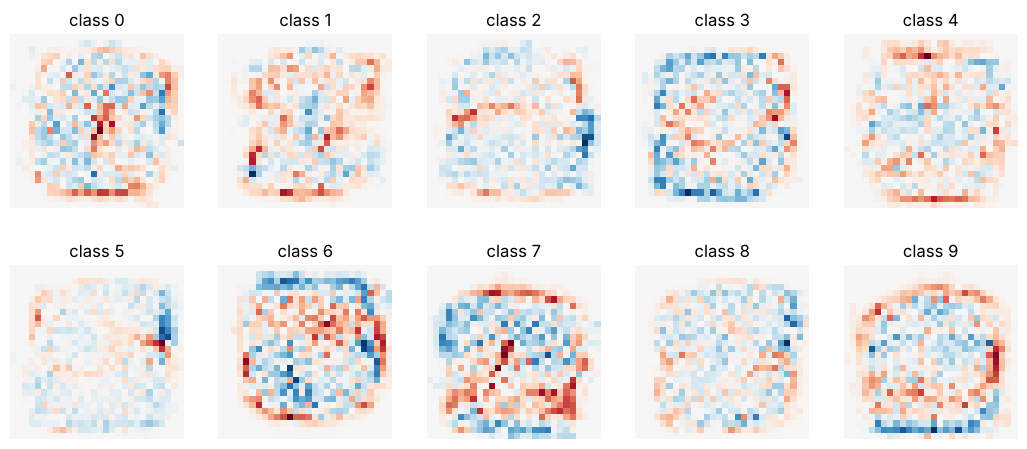

In [28]:
softmax_mm = make_pipeline(MinMaxScaler(), LogisticRegression(max_iter=200, random_state=1729))
softmax_mm.fit(x_train, y_train)
print(f"test accuracy: {softmax_mm.score(x_test, y_test):.4f}")

W = softmax_mm[-1].coef_
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
for k, ax in enumerate(axes.ravel()):
    lim = np.abs(W[k]).max()
    ax.imshow(W[k].reshape(28, 28), cmap='RdBu', vmin=-lim, vmax=lim)
    ax.set_title(f"class {k}"); ax.axis('off')
plt.show()

Not much better: the same speckle from rarely-used border pixels dominates the colour scale. As in the
binary case, a stronger penalty (smaller `C`) is what shrinks those weights.

### LogisticRegressionCV for the multiclass model

The softmax colab tuned `C` with 2-fold CV and micro-averaged F1 (for single-label multiclass, micro F1 is
the same as accuracy). Fewer candidate values here, since every fit on 60,000 images takes a while:

In [29]:
softmax_cv = Pipeline([('scaler', StandardScaler()),
                       ('logreg', LogisticRegressionCV(Cs=[0.01, 0.1, 1.0], cv=2, solver='sag', max_iter=100,
                                                       scoring='f1_micro', random_state=1729, n_jobs=-1))])
softmax_cv.fit(x_train, y_train)
print("best C:", softmax_cv[-1].C_[0])
print(f"test accuracy: {softmax_cv.score(x_test, y_test):.4f}")

best C: 1.0
test accuracy: 0.9252


The default `C=1` comes out best, so the plain model was already about as good as it gets.

## Summary

| model | how it's fitted | regularisation | notes |
|---|---|---|---|
| `SGDClassifier(loss='log_loss')` | SGD | `alpha`, `penalty` | scales to huge data, needs learning rate tuning |
| `LogisticRegression` | lbfgs / saga / ... | `C` (inverse) | default choice, softmax for multiclass |
| `LogisticRegressionCV` | same | picks `C` by CV | faster than a grid search |
| `RidgeClassifier` | closed form | `alpha` | fast, but squared loss isn't ideal for classification |

On MNIST all the linear models land around 90-92% for ten classes and about 99% for the 0-detector.